In [21]:
import numpy as np
import pandas as pd
from variable_leverage_env_3 import agentDLVEnvV3
from variable_leverage_env_2 import agentDLVEnvV2
import os
import shutil
import random
from utils import plot_episode_history_v2, plot_metrics_v3, plot_metrics_v2, plot_economic_metrics, plot

In [22]:
df = pd.read_csv('wbtc_train_data_expanded.csv')
nav = df['nav'].values
nect_price = df['nect_price'].values
vol_token_price = df['wbtc_price'].values
volatile_part = df['wbtc_frac'].values

nav = nav[::4]
nect_price = nect_price[::4]
vol_token_price = vol_token_price[::4]
volatile_part = volatile_part[::4]

In [23]:
N = 0

def naiveAgent(obs, min_cr=1.2, eps=1e-9):
    leverage = obs[0]
    cr = 1/obs[1]
    global N
    if cr <= min_cr + 0.03:
        return 1
    if leverage >= 0.95 or leverage <= 0.05:
        N += 1
        return 1
    else:
        return 0

action scale 1
primordial penalty 0.25
penalty damping 0.9
reward scale 1
reward bound 5
loss scale 0
liquidation penalty 0
risk coef 0
boundary reward scale 0
idle reward 0.05
rebalancing reward 0.2
extravagance penalty 0.1
doing nothing 99.29416649366826 %
action 1 0.7058335063317417 %
action 2 0.0 %
action 3 0.0 %


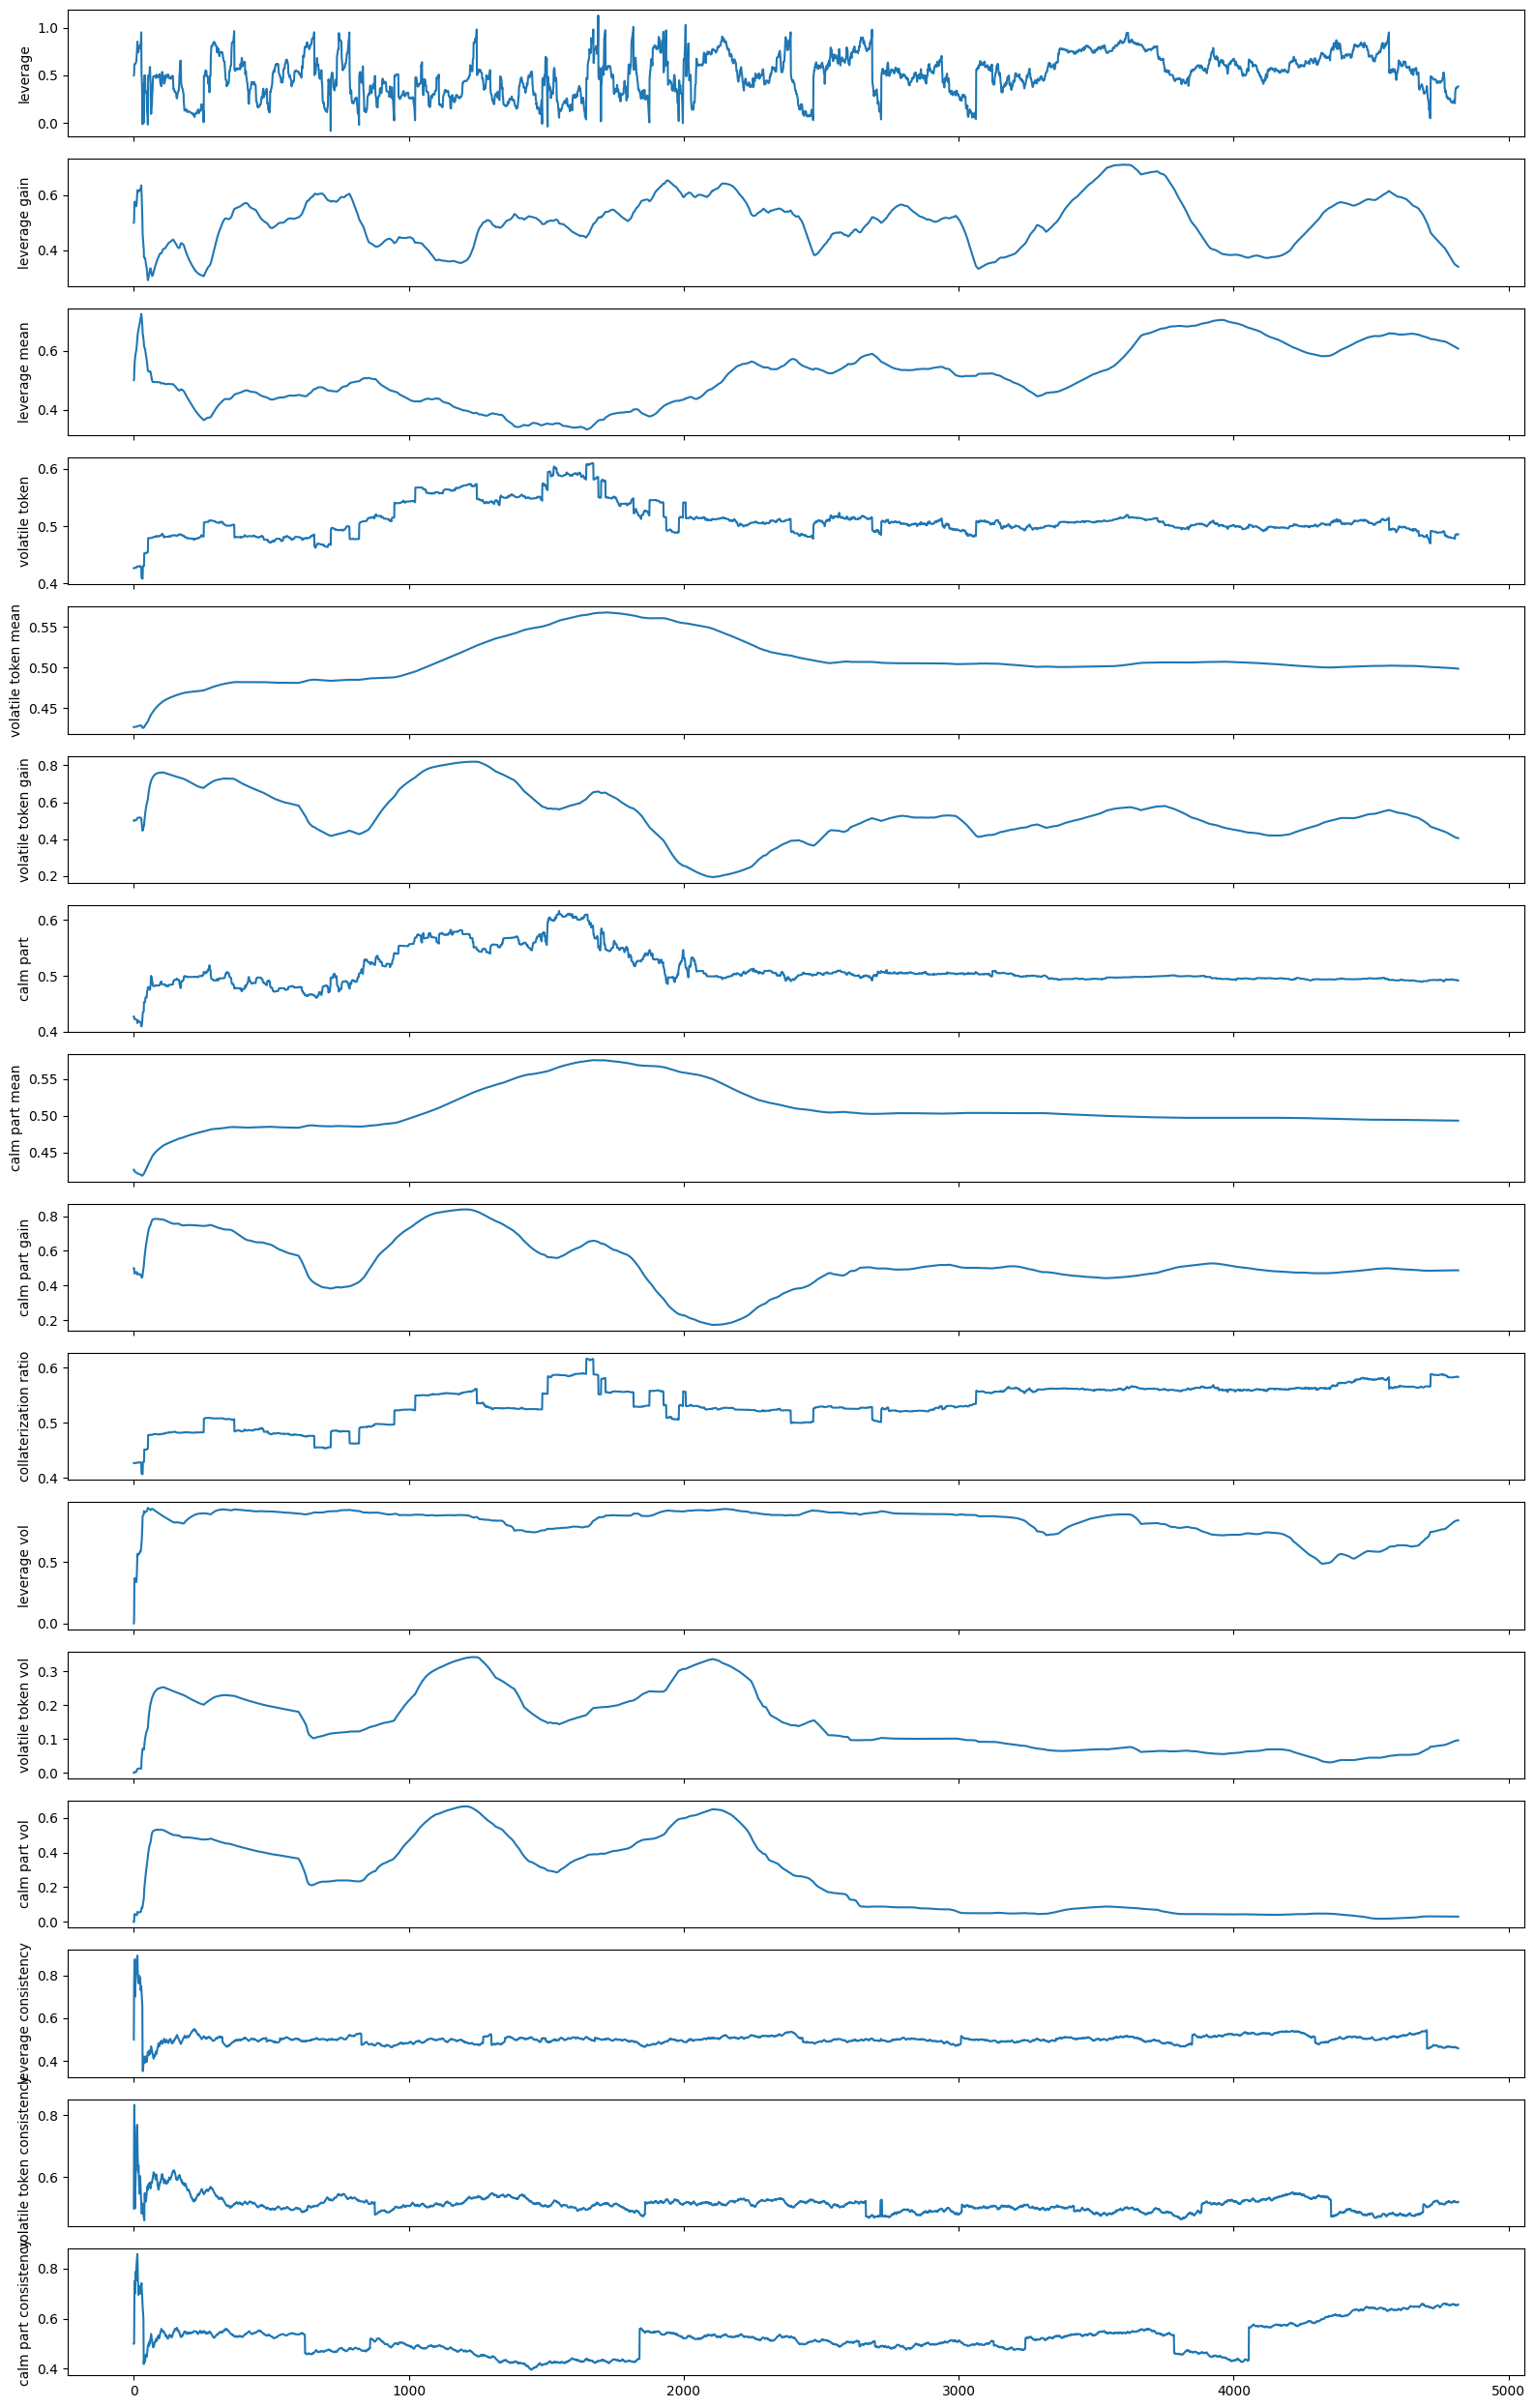

In [30]:
width = 0.1

eval_env= agentDLVEnvV3(
    nect_honey_price = nect_price,
    nav_in_honey = nav,
    vol_part = volatile_part,
    vol_token_honey_price = vol_token_price,
    is_training = False,
    is_mixed = True,
    is_reversed = True,
    top_leverage= 2 + width/2,
    bottom_leverage= 2 - width/2
)

N = 0
obs, _ = eval_env.reset()
done = False

while not done:
    action = naiveAgent(obs)
    obs, reward, terminated, truncated, info = eval_env.step(action)
    done = terminated or truncated

history = info['episode_history']
history_metrics = info['episode_metrics']
economic_metrics = info['episode_economics']
t_l = info['top leverage']
b_l = info['bottom leverage']
not_doing = info.get('0 action')  
action_1 = info.get('0.5 rebalancing') 
action_2 = info.get('0.75 rebalancing') 
action_3 = info.get('0.25 rebalancing') 

print('doing nothing', not_doing*100, '%')
print('action 1', action_1*100, '%')
print('action 2', action_2*100, '%')
print('action 3', action_3*100, '%')

#plot_episode_history_v2(history, t_l, b_l)
plot_metrics_v3(history_metrics)
#plot_economic_metrics(economic_metrics, t_l, b_l)

action scale 1
primordial penalty 0.25
penalty damping 0.9
reward scale 1
reward bound 5
loss scale 0
liquidation penalty 0
risk coef 0
boundary reward scale 0
idle reward 0.05
rebalancing reward 0.2
extravagance penalty 0.1


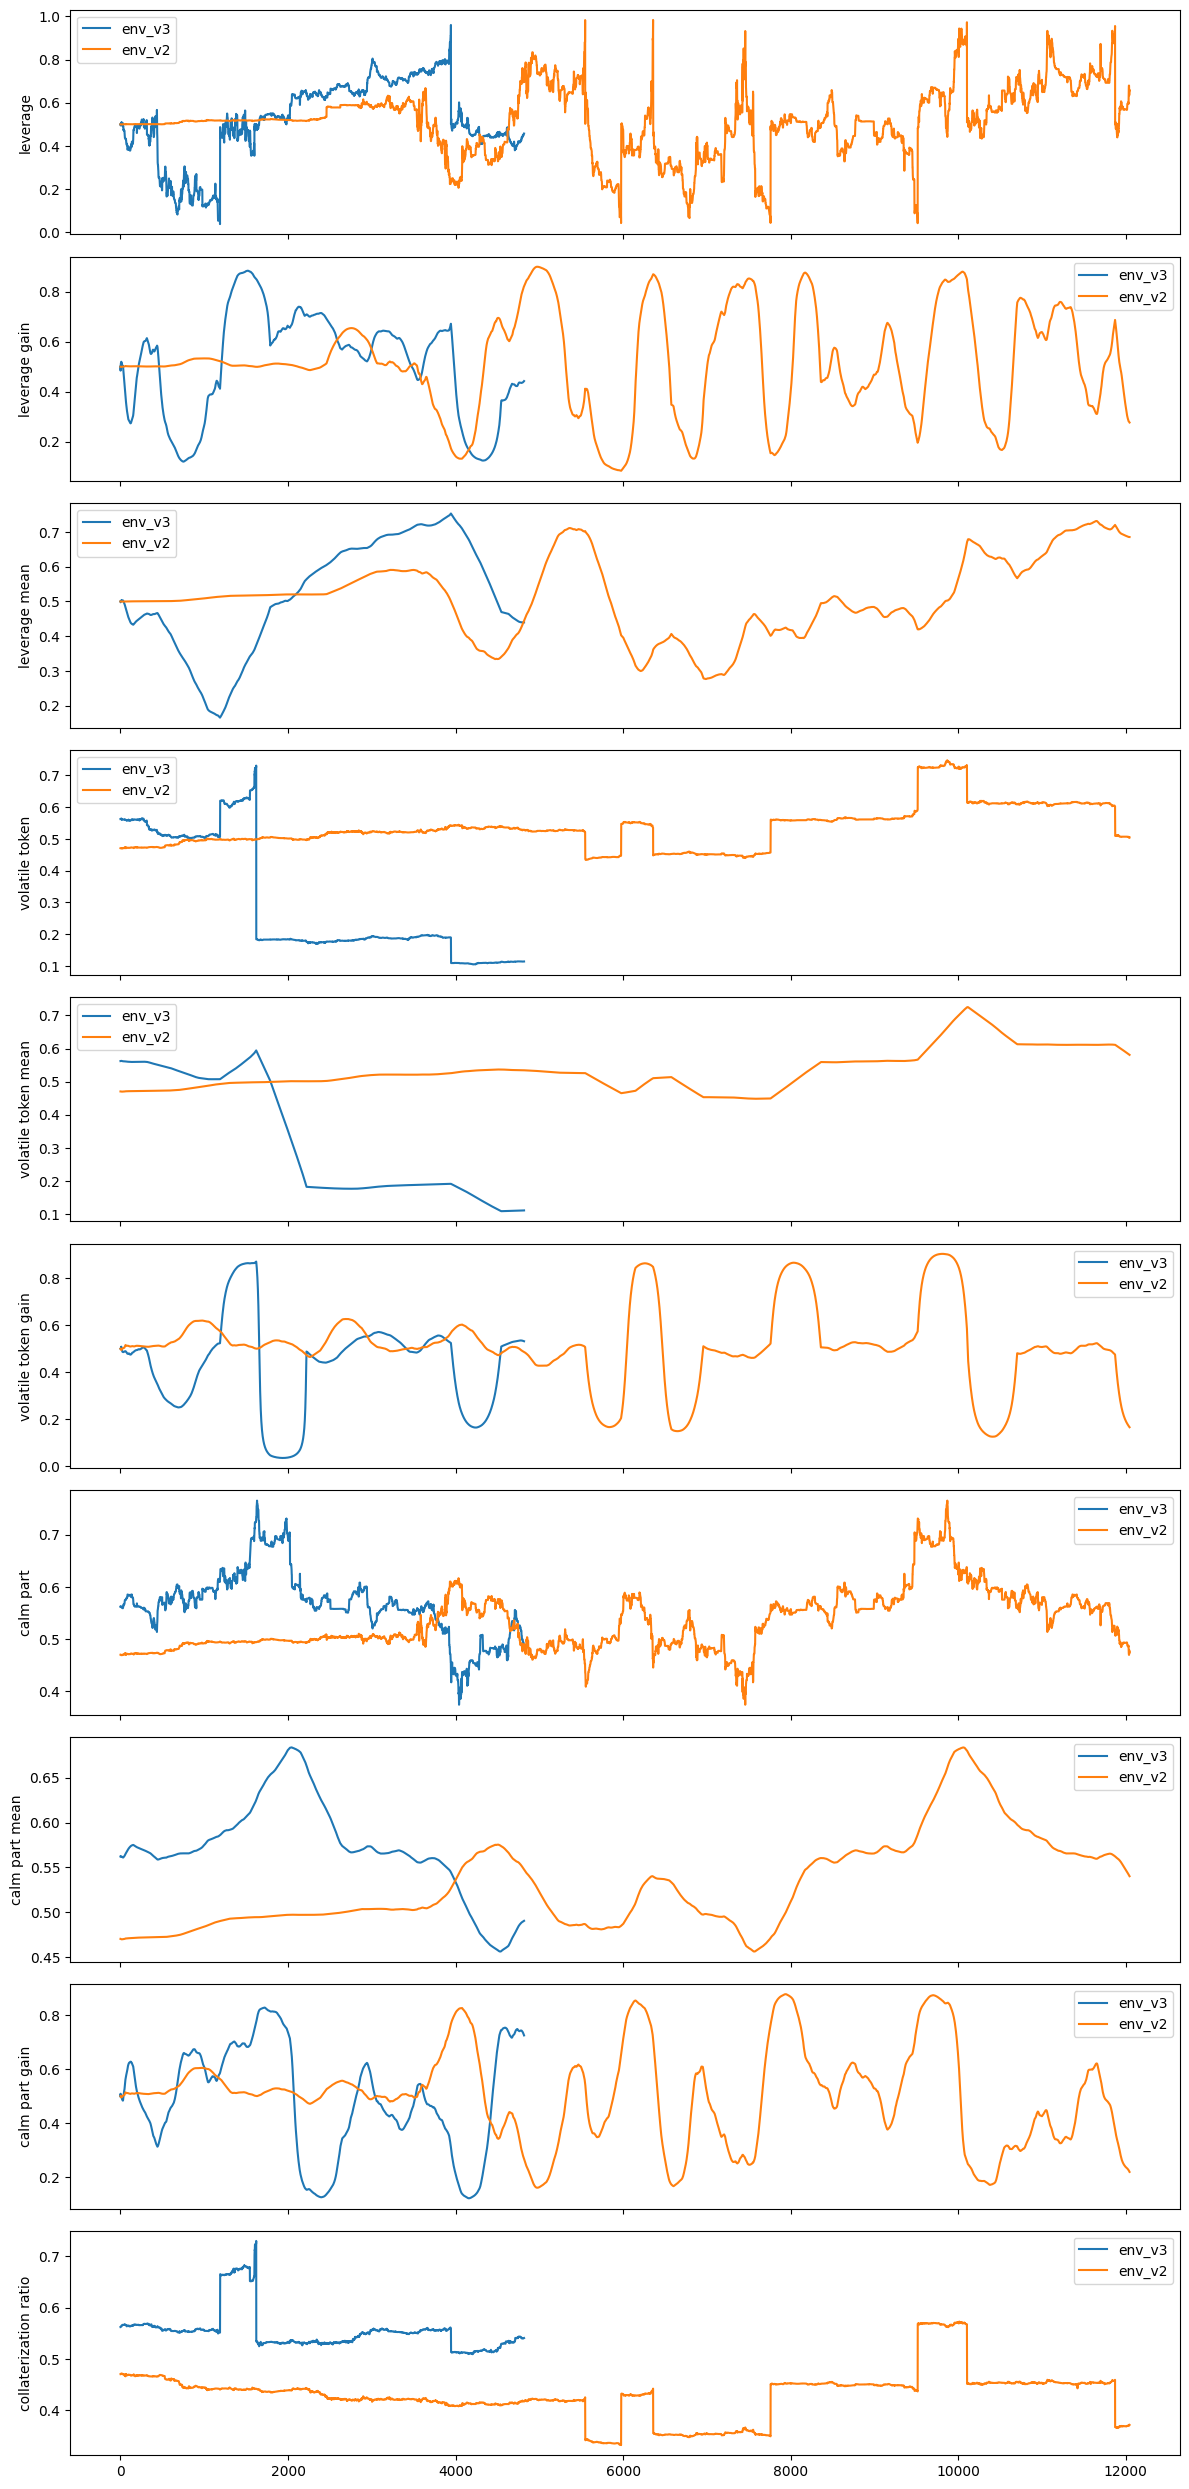

In [25]:
eval_env= agentDLVEnvV2(
    nect_honey_price = nect_price,
    nav_in_honey = nav,
    vol_part = volatile_part,
    vol_token_honey_price = vol_token_price,
    is_training = False,
    is_mixed = False,
    is_reversed = False,
    top_leverage= 2 + width/2,
    bottom_leverage= 2 - width/2
)

N = 0
obs, _ = eval_env.reset()
done = False

while not done:
    action = naiveAgent(obs)
    obs, reward, terminated, truncated, info = eval_env.step(action)
    done = terminated or truncated

history_metrics_v2 = info['episode_metrics']

plot_metrics_v2([history_metrics, history_metrics_v2], ['env_v3', 'env_v2'])

action scale 1
primordial penalty 0.25
penalty damping 0.9
reward scale 1
reward bound 5
loss scale 0
liquidation penalty 0
risk coef 0
boundary reward scale 0
idle reward 0.05
rebalancing reward 0.2
extravagance penalty 0.1
1.1173282583912332e-06


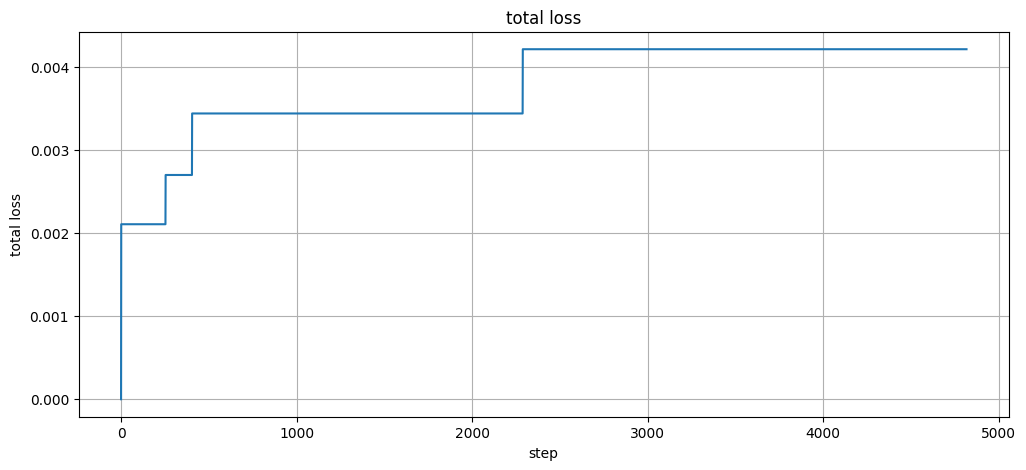

In [26]:
eval_env= agentDLVEnvV3(
    nect_honey_price = nect_price,
    nav_in_honey = nav,
    vol_part = volatile_part,
    vol_token_honey_price = vol_token_price,
    is_training = True,
    is_mixed = True,
    is_reversed = False,
    top_leverage= 2 + width/2,
    bottom_leverage= 2 - width/2
)

N = 0
obs, _ = eval_env.reset()
done = False

while not done:
    action = naiveAgent(obs)
    obs, reward, terminated, truncated, info = eval_env.step(action)
    done = terminated or truncated

print(info['loss_rate'])
plot(
    None,
    info['losses'],
    'step',
    'total loss',
    'total loss'
)



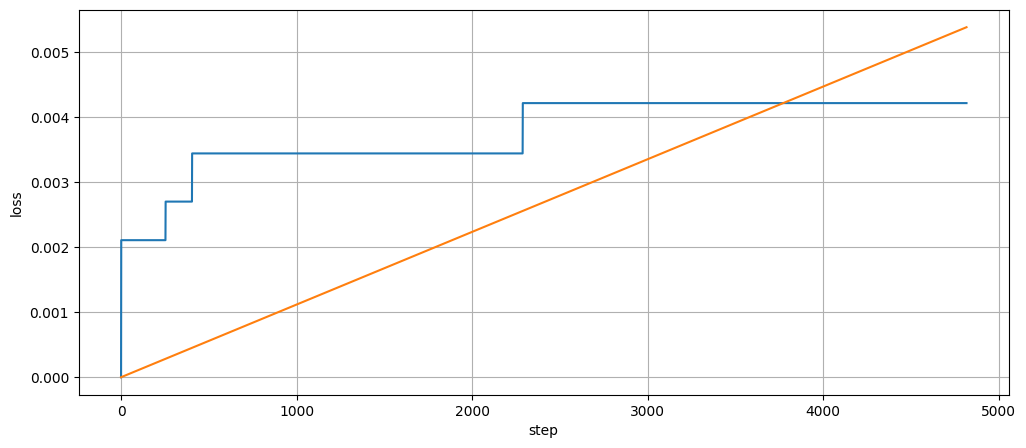

In [27]:
import matplotlib.pyplot as plt

time = np.arange(len(info['losses']))

plt.figure(figsize=(12, 5))
plt.plot(time, info['losses'])
plt.plot(time, time*info['loss_rate'])
plt.xlabel('step')
plt.ylabel('loss')
plt.grid(True)
plt.show()

In [28]:
"""date = timestamp.astype("datetime64[s]")

plot(
    date,
    economic_metrics['leverage'],
    'date',
    'leverage',
    'Mechanical agent leverage'
)

plot(
    date,
    economic_metrics['PNL'],
    'date',
    'PNL',
    'Mechanical agent PNL'
)

plot(
    date,
    np.array(economic_metrics['return'])*100,
    'date',
    'return, %',
    'Mechanical agent return'
)

plot(
    date,
    economic_metrics['collaterization ratio'],
    'date',
    'collaterization ratio',
    'Mechanical agent CR'
)

plot(
    date,
    economic_metrics['vol token amount'],
    'date',
    'WBTC amount',
    'Mechanical agent WBTC amount'
)

plot(
    date,
    economic_metrics['nect debt'],
    'date',
    'NECT debt',
    'Mechanical agent debt'
)

plot(
    date,
    economic_metrics['vol token price'],
    'date',
    'price (in honey)',
    'WBTC price'
)

plot(
    date,
    economic_metrics['nect price'],
    'date',
    'price (in honey)',
    'NECT price'
)

plot(
    date,
    economic_metrics['nav'],
    'date',
    'nav (in honey)',
    'WBTC-HONEY island token nav'
)

plot(
    date,
    np.array(economic_metrics['calm part'])*100,
    'date',
    'calm part, %',
    'WBTC-HONEY island token calm part'
)"""

'date = timestamp.astype("datetime64[s]")\n\nplot(\n    date,\n    economic_metrics[\'leverage\'],\n    \'date\',\n    \'leverage\',\n    \'Mechanical agent leverage\'\n)\n\nplot(\n    date,\n    economic_metrics[\'PNL\'],\n    \'date\',\n    \'PNL\',\n    \'Mechanical agent PNL\'\n)\n\nplot(\n    date,\n    np.array(economic_metrics[\'return\'])*100,\n    \'date\',\n    \'return, %\',\n    \'Mechanical agent return\'\n)\n\nplot(\n    date,\n    economic_metrics[\'collaterization ratio\'],\n    \'date\',\n    \'collaterization ratio\',\n    \'Mechanical agent CR\'\n)\n\nplot(\n    date,\n    economic_metrics[\'vol token amount\'],\n    \'date\',\n    \'WBTC amount\',\n    \'Mechanical agent WBTC amount\'\n)\n\nplot(\n    date,\n    economic_metrics[\'nect debt\'],\n    \'date\',\n    \'NECT debt\',\n    \'Mechanical agent debt\'\n)\n\nplot(\n    date,\n    economic_metrics[\'vol token price\'],\n    \'date\',\n    \'price (in honey)\',\n    \'WBTC price\'\n)\n\nplot(\n    date,\n    ec

In [29]:
"""plot(
    date,
    economic_metrics['nect price'],
    'date',
    'price (in honey)',
    'NECT price'
)

plot(
    date,
    economic_metrics['nav'],
    'date',
    'nav (in honey)',
    'WBTC-HONEY island token nav'
)

plot(
    date,
    np.array(economic_metrics['calm part'])*100,
    'date',
    'calm part, %',
    'WBTC-HONEY island token calm part'
)"""

"plot(\n    date,\n    economic_metrics['nect price'],\n    'date',\n    'price (in honey)',\n    'NECT price'\n)\n\nplot(\n    date,\n    economic_metrics['nav'],\n    'date',\n    'nav (in honey)',\n    'WBTC-HONEY island token nav'\n)\n\nplot(\n    date,\n    np.array(economic_metrics['calm part'])*100,\n    'date',\n    'calm part, %',\n    'WBTC-HONEY island token calm part'\n)"